collega GPU, installa RF-DETR

In [17]:
!pip install -q "rfdetr[train]" supervision

monta drive


In [18]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Definiamo dataset e checkpoint definitivo

In [19]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/"
    "football-adboard-segmentation"
)

DATASET_DIR = PROJECT_DIR / "datasets" / "rf_detr"

CHECKPOINT_PATH = (
    PROJECT_DIR
    / "outputs"
    / "rfdetr_nano_smoke_test_local"
    / "checkpoint_best_total.pth"
)

TEST_DIR = DATASET_DIR / "test"
TEST_JSON = TEST_DIR / "_annotations.coco.json"

print("Test set:", TEST_DIR)
print("Checkpoint:", CHECKPOINT_PATH)

print("\nControlli:")
print("Test esiste:", TEST_DIR.exists())
print("JSON test esiste:", TEST_JSON.exists())
print("Checkpoint esiste:", CHECKPOINT_PATH.exists())

Test set: /content/drive/MyDrive/football-adboard-segmentation/datasets/rf_detr/test
Checkpoint: /content/drive/MyDrive/football-adboard-segmentation/outputs/rfdetr_nano_smoke_test_local/checkpoint_best_total.pth

Controlli:
Test esiste: True
JSON test esiste: True
Checkpoint esiste: True


Carichiamo il modello definitivo

In [20]:
from rfdetr import RFDETRNano

model = RFDETRNano.from_checkpoint(
    str(CHECKPOINT_PATH)
)

print("✓ Best RF-DETR Nano caricato")

/usr/local/lib/python3.12/dist-packages/rfdetr/detr.py:551: FutureWarning: The `RFDETRBase` was deprecated since v1.7.0. It will be removed in v2.0.0.
  getattr(variant_obj, "__name__", symbol): variant_obj
/usr/local/lib/python3.12/dist-packages/rfdetr/detr.py:551: FutureWarning: The `RFDETRLargeDeprecated` was deprecated since v1.7.0. It will be removed in v2.0.0.
  getattr(variant_obj, "__name__", symbol): variant_obj
/usr/local/lib/python3.12/dist-packages/rfdetr/detr.py:551: FutureWarning: The `RFDETRSegPreview` was deprecated since v1.7.0. It will be removed in v2.0.0.
  getattr(variant_obj, "__name__", symbol): variant_obj
[2026-08-21 16:00:19] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-08-21 16:00:19] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is

✓ Best RF-DETR Nano caricato


valutazione sul TEST

In [21]:
test_metrics = model.evaluate(
    dataset_dir=str(DATASET_DIR),
    split="test",
    batch_size=4,
)

print("\n==============================")
print(" RISULTATI FINALI TEST SET")
print("==============================\n")

for key, value in test_metrics.items():
    if isinstance(value, (int, float)):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

[2026-08-21 16:02:24] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-08-21 16:02:24] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-08-21 16:02:25] [INFO] rf-detr - Building Roboflow test dataset with square resize at resolution 384
[2026-08-21 16:02:25] [INFO] rf-detr - Using multi-scale training with square resize and scales: [544]
loading annotations into memory...


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Done (t=0.44s)
creating index...
index created!


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ test/AP/advertising_board │    0.8797164559364319     │
│          test/F1          │    0.9868980646133423     │
│         test/loss         │    1.5889155864715576     │
│        test/mAP_50        │    0.9883272647857666     │
│      test/mAP_50_95       │    0.8797164559364319     │
│        test/mAP_75        │    0.9785847663879395     │
│         test/mAR          │     0.919360339641571     │
│      test/precision       │    0.9870660305023193     │
│        test/recall        │     0.98673015832901      │
└───────────────────────────┴───────────────────────────┘


 RISULTATI FINALI TEST SET

test/loss: 1.5889
test/mAP_50_95: 0.8797
test/mAP_50: 0.9883
test/mAP_75: 0.9786
test/mAR: 0.9194
test/F1: 0.9869
test/precision: 0.9871
test/recall: 0.9867
test/AP/advertising_board: 0.8797


In [22]:
import json

TEST_METRICS_PATH = (
    PROJECT_DIR
    / "outputs"
    / "rfdetr_nano_test_metrics.json"
)

clean_metrics = {
    key: float(value)
    for key, value in test_metrics.items()
}

with TEST_METRICS_PATH.open("w", encoding="utf-8") as f:
    json.dump(
        clean_metrics,
        f,
        indent=4
    )

print("Metriche salvate in:")
print(TEST_METRICS_PATH)

Metriche salvate in:
/content/drive/MyDrive/football-adboard-segmentation/outputs/rfdetr_nano_test_metrics.json


Immagine: uky4kicj12n46r2.png


[2026-08-21 09:57:55] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. For full GPU throughput (e.g. ~8x on T4 via FP16 Tensor Cores), call model.inference(dtype=torch.float16).


Detection trovate: 1


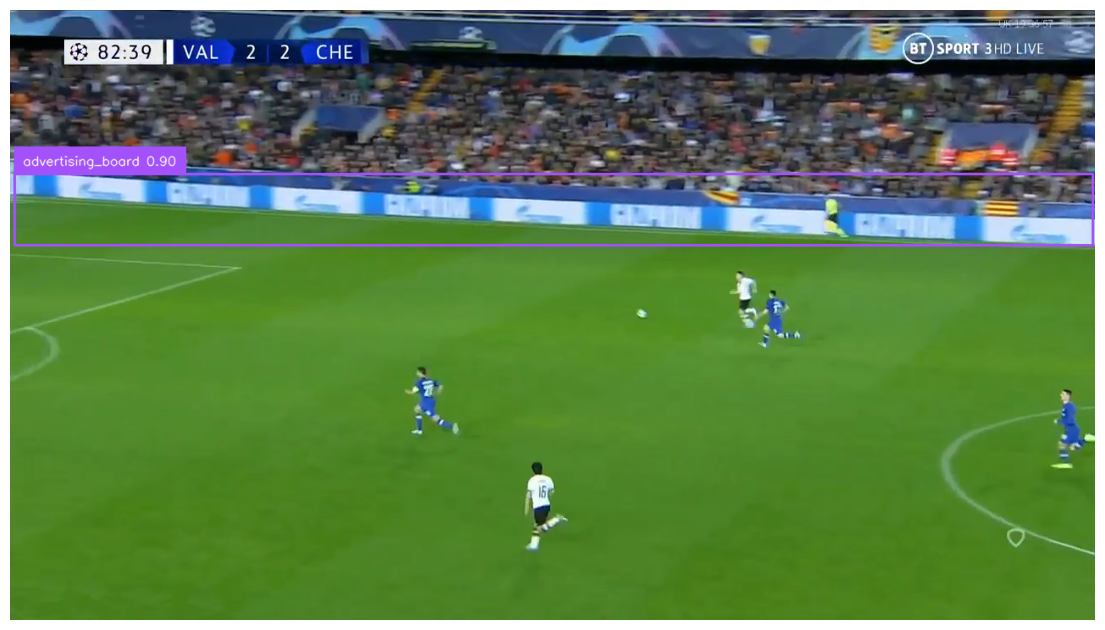

In [5]:
import json
from PIL import Image
import supervision as sv
import matplotlib.pyplot as plt

# Legge il COCO della validation
with VALID_JSON.open("r", encoding="utf-8") as f:
    coco = json.load(f)

# Prendiamo la prima immagine del validation set
image_info = coco["images"][0]
image_path = VALID_DIR / image_info["file_name"]

print("Immagine:", image_path.name)

image = Image.open(image_path).convert("RGB")

# Inferenza RF-DETR
detections = model.predict(
    image,
    threshold=0.5
)

print("Detection trovate:", len(detections))

# Etichette da visualizzare
labels = [
    f"advertising_board {confidence:.2f}"
    for confidence in detections.confidence
]

# Disegna le predizioni
annotated_image = sv.BoxAnnotator().annotate(
    image.copy(),
    detections
)

annotated_image = sv.LabelAnnotator().annotate(
    annotated_image,
    detections,
    labels=labels
)

plt.figure(figsize=(14, 8))
plt.imshow(annotated_image)
plt.axis("off")
plt.show()

Ground truth presenti: 1
Predizioni RF-DETR: 1


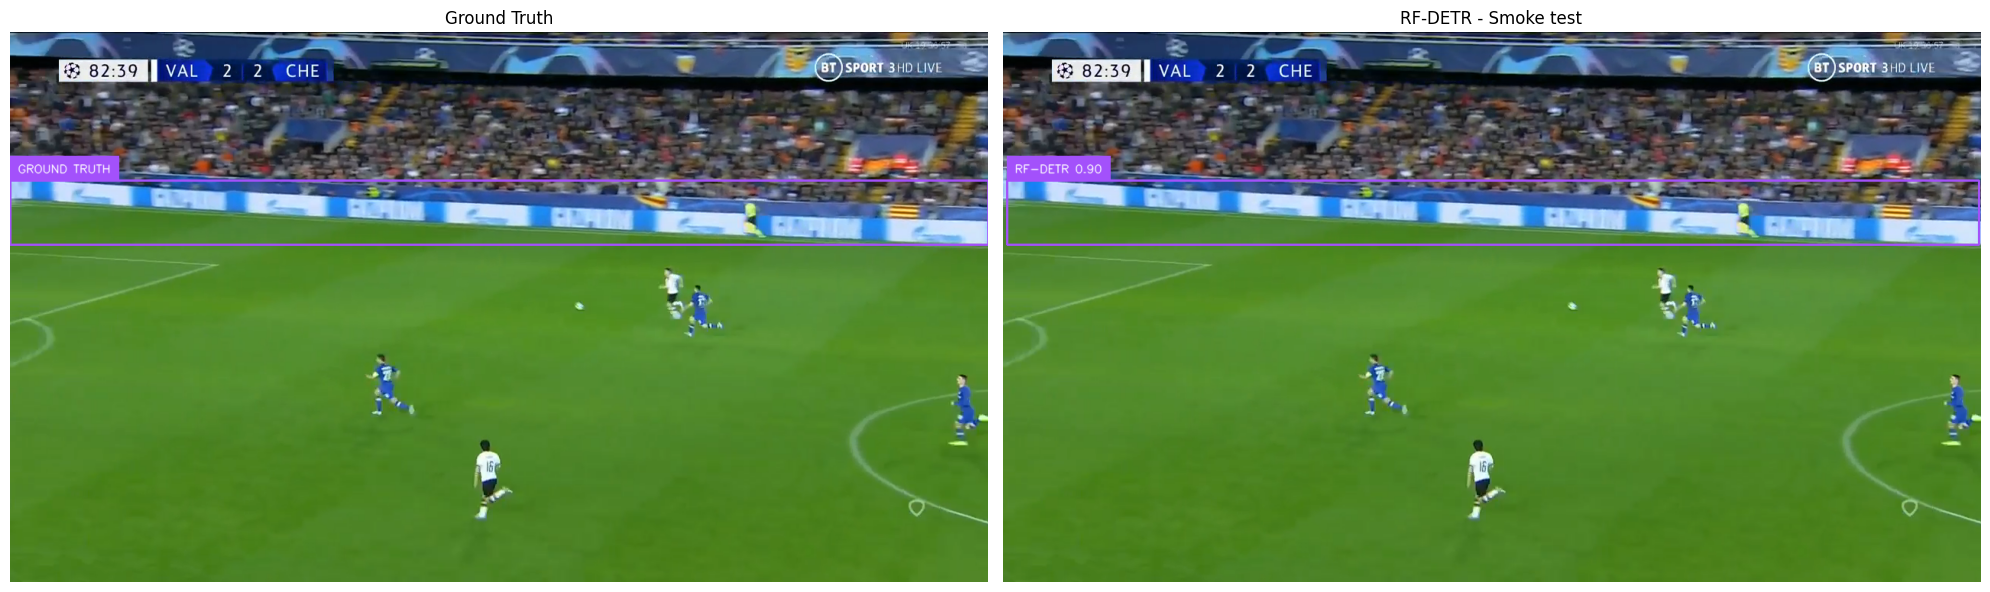

In [7]:
import numpy as np
import supervision as sv
import matplotlib.pyplot as plt

# ID dell'immagine visualizzata
image_id = image_info["id"]

# Recupera le annotazioni ground truth di questa immagine
gt_annotations = [
    ann
    for ann in coco["annotations"]
    if ann["image_id"] == image_id
]

print("Ground truth presenti:", len(gt_annotations))
print("Predizioni RF-DETR:", len(detections))

# COCO bbox = [x, y, width, height]
gt_xyxy = []

for ann in gt_annotations:
    x, y, w, h = ann["bbox"]

    gt_xyxy.append([
        x,
        y,
        x + w,
        y + h
    ])

gt_xyxy = np.array(gt_xyxy, dtype=float)

gt_detections = sv.Detections(
    xyxy=gt_xyxy,
    class_id=np.zeros(len(gt_xyxy), dtype=int)
)

# Immagine 1: ground truth
gt_image = sv.BoxAnnotator().annotate(
    scene=image.copy(),
    detections=gt_detections
)

gt_labels = ["GROUND TRUTH"] * len(gt_detections)

gt_image = sv.LabelAnnotator().annotate(
    scene=gt_image,
    detections=gt_detections,
    labels=gt_labels
)

# Immagine 2: RF-DETR
pred_image = sv.BoxAnnotator().annotate(
    scene=image.copy(),
    detections=detections
)

pred_labels = [
    f"RF-DETR {conf:.2f}"
    for conf in detections.confidence
]

pred_image = sv.LabelAnnotator().annotate(
    scene=pred_image,
    detections=detections,
    labels=pred_labels
)

# Confronto
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

axes[0].imshow(gt_image)
axes[0].set_title("Ground Truth")
axes[0].axis("off")

axes[1].imshow(pred_image)
axes[1].set_title("RF-DETR - Smoke test")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [8]:
import numpy as np

gt_box = gt_detections.xyxy[0]

# Prendiamo la predizione con confidence maggiore
best_idx = np.argmax(detections.confidence)
pred_box = detections.xyxy[best_idx]

def calculate_iou(box_a, box_b):
    x1 = max(box_a[0], box_b[0])
    y1 = max(box_a[1], box_b[1])
    x2 = min(box_a[2], box_b[2])
    y2 = min(box_a[3], box_b[3])

    intersection_w = max(0, x2 - x1)
    intersection_h = max(0, y2 - y1)
    intersection = intersection_w * intersection_h

    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])

    union = area_a + area_b - intersection

    return intersection / union if union > 0 else 0

iou = calculate_iou(gt_box, pred_box)

print("Ground truth:", gt_box)
print("RF-DETR:", pred_box)
print(f"Confidence: {detections.confidence[best_idx]:.4f}")
print(f"IoU: {iou:.4f}")

Ground truth: [   0.  194. 1280.  278.]
RF-DETR: [   5.802803  194.19952  1277.7772    278.57486 ]
Confidence: 0.9016
IoU: 0.9847


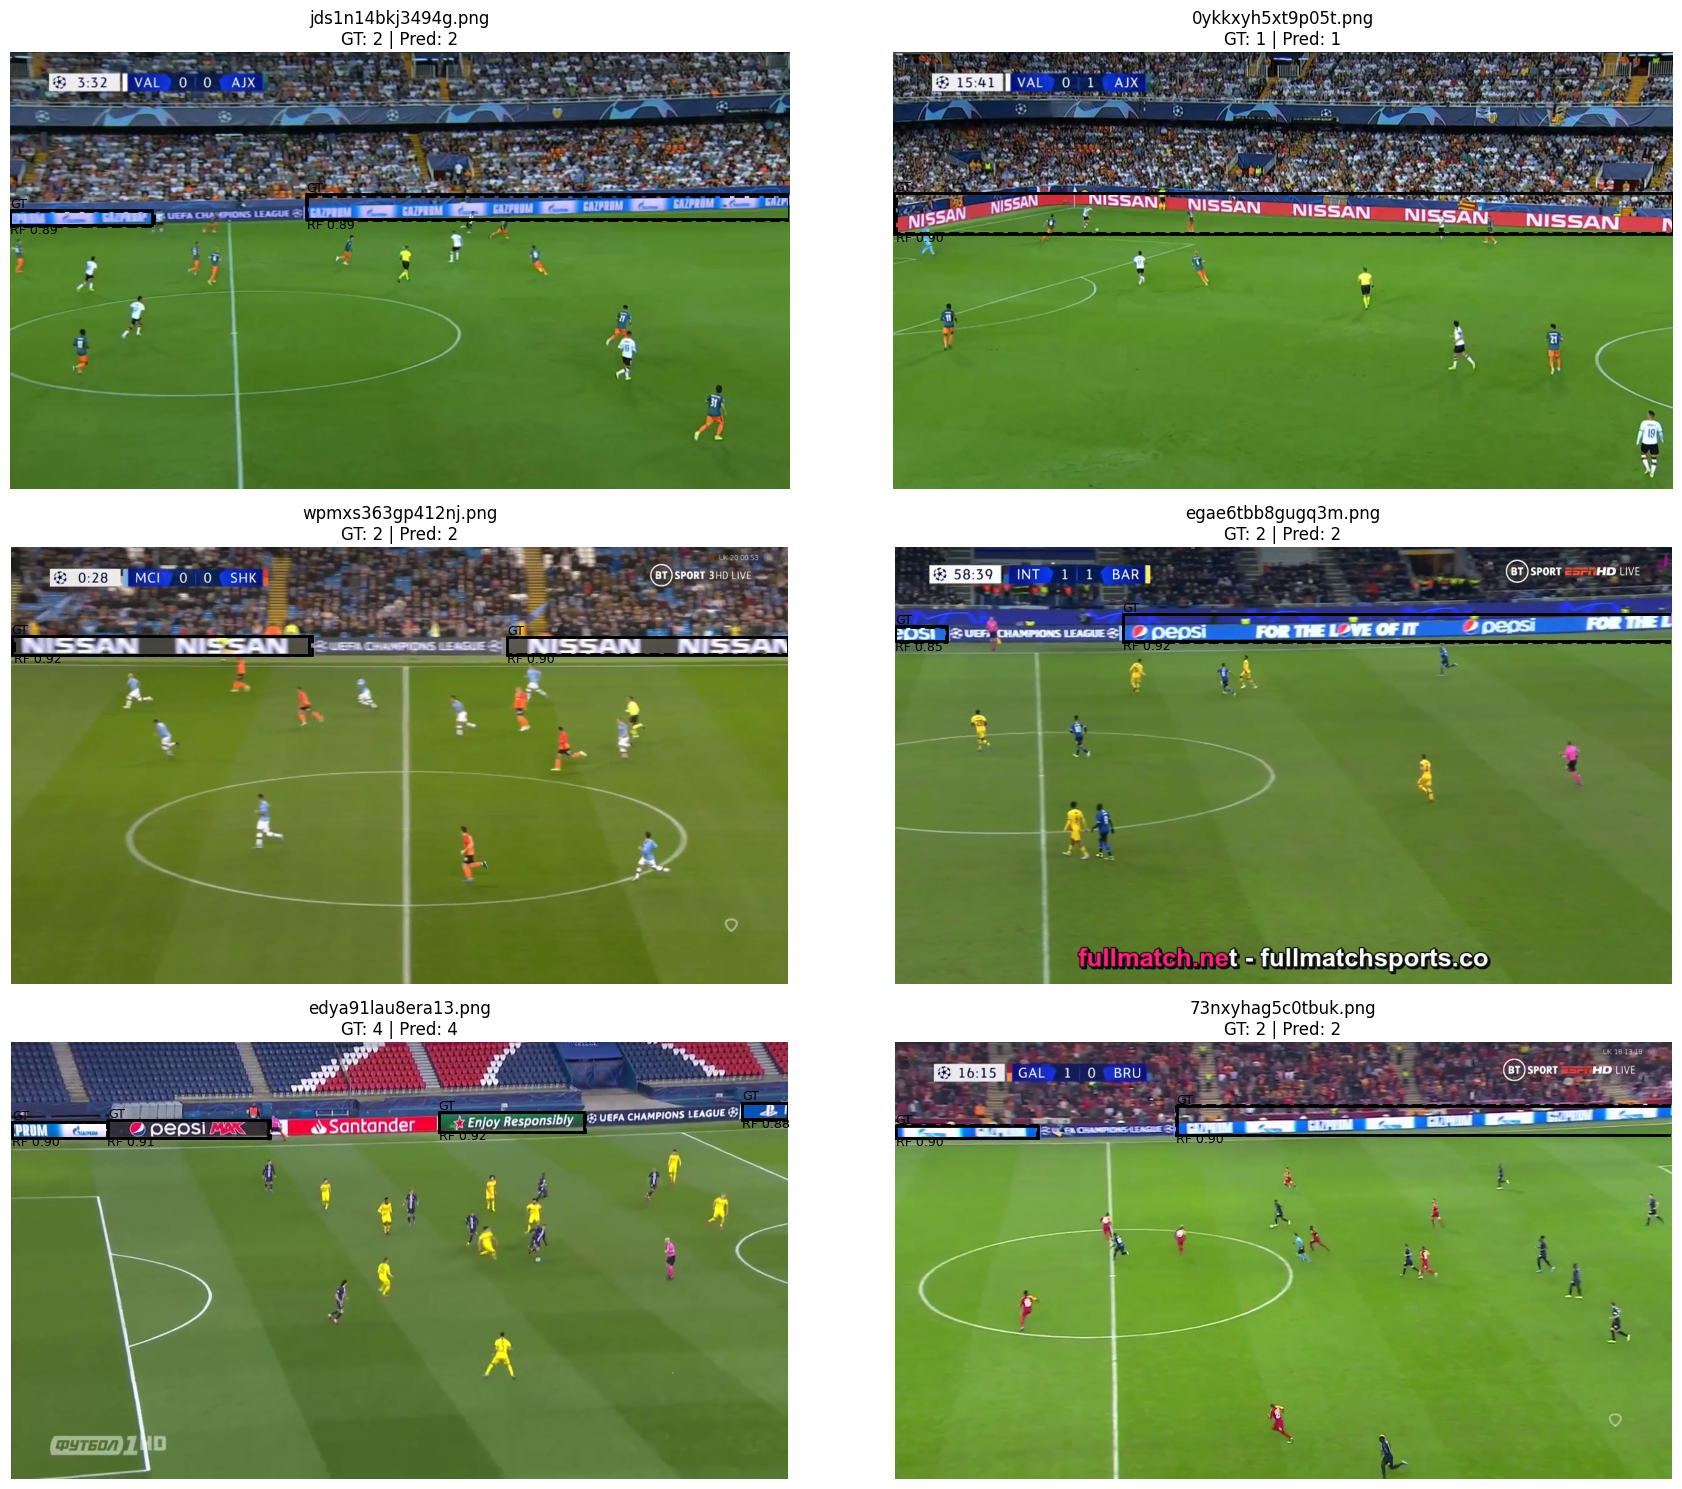

In [9]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

random.seed(42)

sample_infos = random.sample(coco["images"], 6)

fig, axes = plt.subplots(3, 2, figsize=(18, 15))
axes = axes.ravel()

for ax, info in zip(axes, sample_infos):

    image_path = VALID_DIR / info["file_name"]
    img = Image.open(image_path).convert("RGB")

    # Predizioni
    preds = model.predict(
        img,
        threshold=0.5
    )

    # Ground truth
    gt_anns = [
        ann
        for ann in coco["annotations"]
        if ann["image_id"] == info["id"]
    ]

    ax.imshow(img)

    # Ground truth: linea continua
    for ann in gt_anns:
        x, y, w, h = ann["bbox"]

        rect = patches.Rectangle(
            (x, y),
            w,
            h,
            linewidth=2,
            fill=False,
            linestyle="-"
        )

        ax.add_patch(rect)
        ax.text(
            x,
            y - 5,
            "GT",
            fontsize=9
        )

    # Predizioni RF-DETR: linea tratteggiata
    for box, conf in zip(preds.xyxy, preds.confidence):
        x1, y1, x2, y2 = box

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            fill=False,
            linestyle="--"
        )

        ax.add_patch(rect)
        ax.text(
            x1,
            y2 + 12,
            f"RF {conf:.2f}",
            fontsize=9
        )

    ax.set_title(
        f"{info['file_name']}\n"
        f"GT: {len(gt_anns)} | Pred: {len(preds)}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [10]:
import json
import random

# Ricarichiamo il COCO della validation
with VALID_JSON.open("r", encoding="utf-8") as f:
    coco = json.load(f)

# Campione riproducibile
random.seed(42)

REVIEW_SIZE = 50

review_images = random.sample(
    coco["images"],
    REVIEW_SIZE
)

print("Immagini selezionate:", len(review_images))
print("Prime 5:")

for info in review_images[:5]:
    print("-", info["file_name"])

Immagini selezionate: 50
Prime 5:
- jds1n14bkj3494g.png
- 0ykkxyh5xt9p05t.png
- wpmxs363gp412nj.png
- egae6tbb8gugq3m.png
- edya91lau8era13.png


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output

review_results = {}
current_index = 0

output = widgets.Output()

btn_complete = widgets.Button(
    description="✅ Completa",
    button_style="success"
)

btn_incomplete = widgets.Button(
    description="❌ Incompleta",
    button_style="danger"
)

btn_ambiguous = widgets.Button(
    description="❓ Ambigua",
    button_style="warning"
)

btn_previous = widgets.Button(
    description="← Indietro"
)

progress_label = widgets.Label()


def get_annotations(image_id):
    return [
        ann
        for ann in coco["annotations"]
        if ann["image_id"] == image_id
    ]


def show_current():
    global current_index

    with output:
        clear_output(wait=True)

        if current_index >= len(review_images):
            print("✓ Revisione completata")
            return

        info = review_images[current_index]
        image_path = VALID_DIR / info["file_name"]

        image = Image.open(image_path).convert("RGB")
        annotations = get_annotations(info["id"])

        # Originale + Ground Truth
        fig, axes = plt.subplots(1, 2, figsize=(18, 7))

        axes[0].imshow(image)
        axes[0].set_title("Immagine originale")
        axes[0].axis("off")

        axes[1].imshow(image)

        for ann in annotations:
            x, y, w, h = ann["bbox"]

            rect = patches.Rectangle(
                (x, y),
                w,
                h,
                linewidth=2,
                fill=False
            )

            axes[1].add_patch(rect)
            axes[1].text(
                x,
                max(0, y - 5),
                "GT",
                fontsize=9
            )

        axes[1].set_title(
            f"Ground Truth — {len(annotations)} box"
        )
        axes[1].axis("off")

        plt.suptitle(
            f"{current_index + 1}/{len(review_images)} — "
            f"{info['file_name']}"
        )

        plt.tight_layout()
        plt.show()

        previous_result = review_results.get(
            info["file_name"],
            "non classificata"
        )

        print("Classificazione attuale:", previous_result)

    progress_label.value = (
        f"Revisionate: {len(review_results)}/{len(review_images)}"
    )


def register_result(label):
    global current_index

    info = review_images[current_index]

    review_results[info["file_name"]] = label

    current_index += 1

    show_current()


def on_complete(_):
    register_result("complete")


def on_incomplete(_):
    register_result("incomplete")


def on_ambiguous(_):
    register_result("ambiguous")


def on_previous(_):
    global current_index

    if current_index > 0:
        current_index -= 1

    show_current()


btn_complete.on_click(on_complete)
btn_incomplete.on_click(on_incomplete)
btn_ambiguous.on_click(on_ambiguous)
btn_previous.on_click(on_previous)

buttons = widgets.HBox([
    btn_complete,
    btn_incomplete,
    btn_ambiguous,
    btn_previous
])

display(progress_label)
display(buttons)
display(output)

show_current()

Label(value='')

Output()

In [12]:
from collections import Counter

counts = Counter(review_results.values())

print("RISULTATI REVISIONE")
print("--------------------")
print("Complete   :", counts["complete"])
print("Incomplete :", counts["incomplete"])
print("Ambigue    :", counts["ambiguous"])
print("Totale     :", len(review_results))

RISULTATI REVISIONE
--------------------
Complete   : 14
Incomplete : 28
Ambigue    : 8
Totale     : 50


In [13]:
total = len(review_results)

for label in ("complete", "incomplete", "ambiguous"):
    n = counts[label]
    percentage = 100 * n / total

    print(
        f"{label:10s}: "
        f"{n:2d}/{total} "
        f"({percentage:.1f}%)"
    )

complete  : 14/50 (28.0%)
incomplete: 28/50 (56.0%)
ambiguous :  8/50 (16.0%)


In [15]:
from pathlib import Path
import pandas as pd

rows = []

for info in review_images:
    filename = info["file_name"]

    rows.append({
        "file_name": filename,
        "image_id": info["id"],
        "classification": review_results.get(filename)
    })

review_df = pd.DataFrame(rows)

REVIEW_DIR = (
    PROJECT_DIR
    / "outputs"
    / "dataset_review"
)

REVIEW_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CSV_PATH = REVIEW_DIR / "validation_annotation_review_50.csv"

review_df.to_csv(
    CSV_PATH,
    index=False
)

print("File salvato:")
print(CSV_PATH)

print("\nDistribuzione:")
print(review_df["classification"].value_counts())

File salvato:
/content/drive/MyDrive/football-adboard-segmentation/outputs/dataset_review/validation_annotation_review_50.csv

Distribuzione:
classification
incomplete    28
complete      14
ambiguous      8
Name: count, dtype: int64
